## Section 1
## Importing Neccessary Libraries

In [94]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score,root_mean_squared_error 
from sklearn.preprocessing import TargetEncoder,OrdinalEncoder
from sklearn.model_selection import train_test_split

In [66]:
df=pd.read_csv("Ames_Housing_Dataset_Train.csv")
df.head(5)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## Section 2
## EDA and X / Y Features Comparison

In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [68]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [69]:
x=[]
y=[]
for i in df:
    
    if df[i].count() < 1460:
        x.append(i)
        y.append(df[i].count())
        
df_3=pd.DataFrame({"Columns":x,"Missing Values":y})
print("\033[1m"+"  Columns With Missing Values"+"\033[0m")
df_3

  Columns With Missing Values


,Columns,Missing Values
0,LotFrontage,1201
1,Alley,91
2,MasVnrType,588
3,MasVnrArea,1452
4,BsmtQual,1423
5,BsmtCond,1423
6,BsmtExposure,1422
7,BsmtFinType1,1423
8,BsmtFinType2,1422
9,Electrical,1459


In [70]:
Numerical_Columns=[]

for i in df:
    
    if df[i].dtype == "int64" or "float64" and df[i].dtype!="O":
     
        Numerical_Columns.append(i)
        

for i in range(5):
    Numerical_Columns.append("na")
        


    
Categorical_Columns=[]

for i in df:
    
    if df[i].dtype == "O":
        
        
        Categorical_Columns.append(i)
        


print("\033[1m"+"Top 10 Catagorical Columns/Numerical Columns"+"\033[0m")
pd.DataFrame({"Numerical_Columns":Numerical_Columns,"Categorical_Columns":Categorical_Columns}).head(10)

Top 10 Catagorical Columns/Numerical Columns


,Numerical_Columns,Categorical_Columns
0,Id,MSZoning
1,MSSubClass,Street
2,LotFrontage,Alley
3,LotArea,LotShape
4,OverallQual,LandContour
5,OverallCond,Utilities
6,YearBuilt,LotConfig
7,YearRemodAdd,LandSlope
8,MasVnrArea,Neighborhood
9,BsmtFinSF1,Condition1


In [71]:
df["SalePrice"].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

Text(0.5, 1.0, 'Sales Price Distribution')

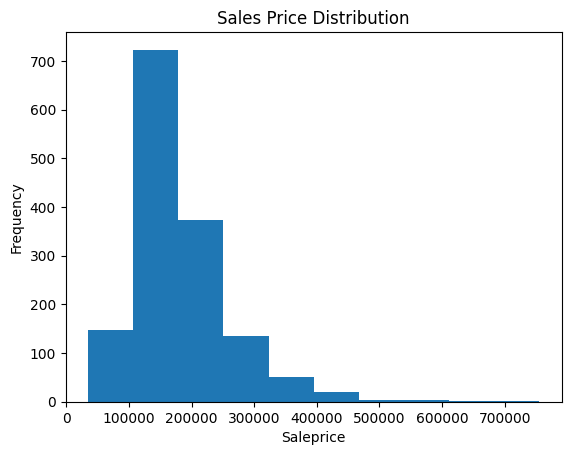

In [72]:
plt.hist(df["SalePrice"])
plt.xlabel("Saleprice")
plt.ylabel("Frequency")
plt.title("Sales Price Distribution")

### SALES PRICE IS RIGHT SKEWED

In [73]:
df["GarageArea"]

0       548
1       460
2       608
3       642
4       836
       ... 
1455    460
1456    500
1457    252
1458    240
1459    276
Name: GarageArea, Length: 1460, dtype: int64

,SalePrice,GarageArea
SalePrice,1.000000,0.623431
GarageArea,0.623431,1.000000


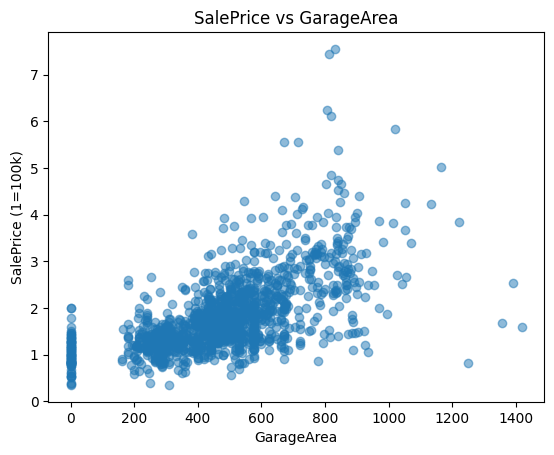

In [74]:
plt.scatter(df["GarageArea"],df["SalePrice"]/100000,alpha=0.5)
plt.title("SalePrice vs GarageArea")
plt.xlabel("GarageArea")
plt.ylabel("SalePrice (1=100k)")
df[["SalePrice","GarageArea"]].corr()


,SalePrice,BedroomAbvGr
SalePrice,1.000000,0.168213
BedroomAbvGr,0.168213,1.000000


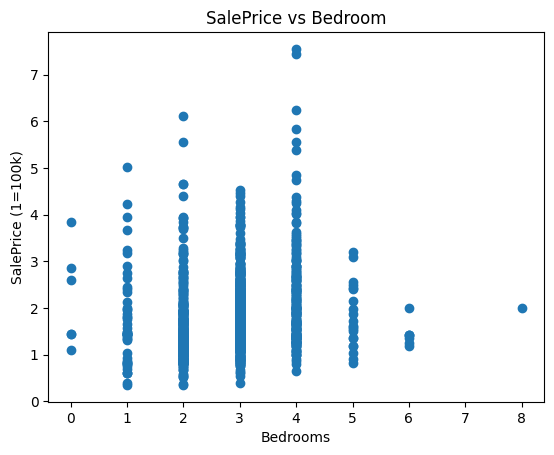

In [75]:
plt.scatter(df["BedroomAbvGr"],df["SalePrice"]/100000)
plt.title("SalePrice vs Bedroom")
plt.xlabel("Bedrooms")
plt.ylabel("SalePrice (1=100k)")
df[["SalePrice","BedroomAbvGr"]].corr()

,SalePrice,KitchenAbvGr
SalePrice,1.000000,-0.135907
KitchenAbvGr,-0.135907,1.000000


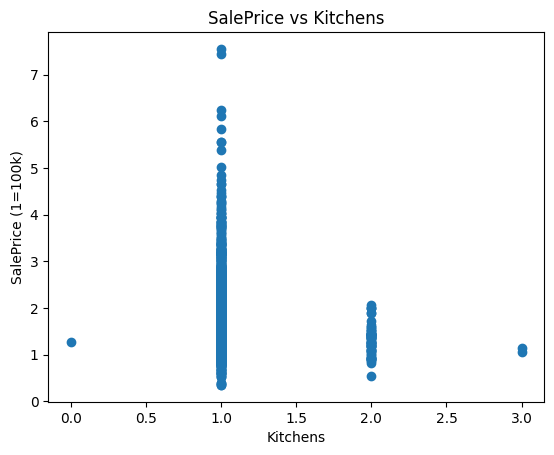

In [76]:
plt.scatter(df["KitchenAbvGr"],df["SalePrice"]/100000)
plt.title("SalePrice vs Kitchens")
plt.xlabel("Kitchens")
plt.ylabel("SalePrice (1=100k)")
df[["SalePrice","KitchenAbvGr"]].corr()

In [ ]:
grpby_df=df.groupby("KitchenQual")["SalePrice"].mean()
df_2=round(grpby_df,2)
x=df_2.index.to_list()
y=df_2.values


numpy.ndarray

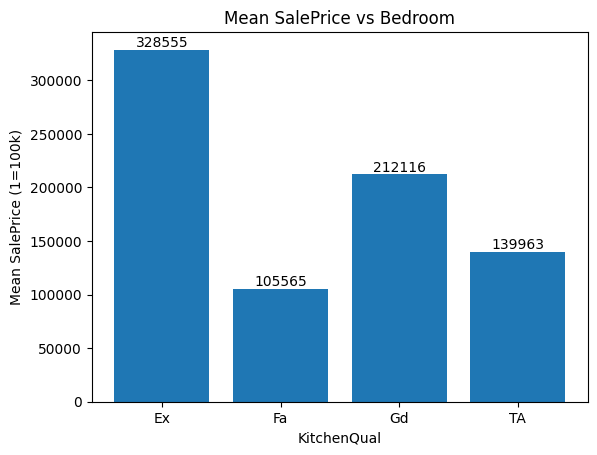

In [78]:
bar=plt.bar(x,y)
plt.bar_label(bar,label=y)
plt.title("Mean SalePrice vs Bedroom")
plt.xlabel("KitchenQual")
plt.ylabel("Mean SalePrice (1=100k)") 
plt.show()
   

# Section 3

## Handling Missing Values

In [79]:
x=[]
y=[]
for i in df:
    
    if df[i].count() < 1460:
        x.append(i)
        y.append(df[i].count())
        
df_3=pd.DataFrame({"Columns":x,"Number Of Rows":y})
print("\033[1m"+"  Columns With Number Of Rows"+"\033[0m")
df_3

  Columns With Number Of Rows


,Columns,Number Of Rows
0,LotFrontage,1201
1,Alley,91
2,MasVnrType,588
3,MasVnrArea,1452
4,BsmtQual,1423
5,BsmtCond,1423
6,BsmtExposure,1422
7,BsmtFinType1,1423
8,BsmtFinType2,1422
9,Electrical,1459


In [80]:
df[["Electrical"]].value_counts()

Electrical
SBrkr         1334
FuseA           94
FuseF           27
FuseP            3
Mix              1
Name: count, dtype: int64

### Dropping MasVnr columns because they merely affect the y data point



In [81]:
df=df.drop("MasVnrType",axis=1)
df=df.drop("MasVnrArea",axis=1)

### Filling Numerical Columns with 0

In [82]:
df["LotFrontage"]=df["LotFrontage"].fillna(0)
df["GarageYrBlt"]=df["GarageYrBlt"].fillna(0)

### Filling Categorical Columns with "None" which will help us in oridnal encoding


In [83]:
df["FireplaceQu"]

0       NaN
1        TA
2        TA
3        Gd
4        TA
       ... 
1455     TA
1456     TA
1457     Gd
1458    NaN
1459    NaN
Name: FireplaceQu, Length: 1460, dtype: object

In [84]:
df["Alley"]=df["Alley"].fillna("None")
df["FireplaceQu"]=df["FireplaceQu"].fillna("None")
df["PoolQC"]=df["PoolQC"].fillna("None")
df["Fence"]=df["Fence"].fillna("None")
df["MiscFeature"]=df["MiscFeature"].fillna("None")
df["BsmtCond"]=df["BsmtCond"].fillna("None")
df["BsmtQual"]=df["BsmtQual"].fillna("None")
df["BsmtExposure"]=df["BsmtExposure"].fillna("None")
df["BsmtFinType1"]=df["BsmtFinType1"].fillna("None")
df["BsmtFinType2"]=df["BsmtFinType2"].fillna("None")
df["Electrical"]=df["Electrical"].fillna("None")
df["GarageType"]=df["GarageType"].fillna("None")
df["GarageYrBlt"]=df["GarageYrBlt"].fillna("None")
df["GarageFinish"]=df["GarageFinish"].fillna("None")
df["GarageQual"]=df["GarageQual"].fillna("None")
df["GarageCond"]=df["GarageCond"].fillna("None")

### Performing Ordinal Encoding on Non-Nominal Features 

In [87]:
from sklearn.preprocessing import OrdinalEncoder


ordinal_dict = {
    "ExterQual": ["Po", "Fa", "TA", "Gd", "Ex"],
    "ExterCond": ["Po", "Fa", "TA", "Gd", "Ex"],
    "BsmtQual": ["NA", "Po", "Fa", "TA", "Gd", "Ex"],
    "BsmtCond": ["NA", "Po", "Fa", "TA", "Gd", "Ex"],
    "BsmtExposure": ["NA", "No", "Mn", "Av", "Gd"],
    "BsmtFinType1": ["NA", "Unf", "LwQ", "Rec", "BLQ", "ALQ", "GLQ"],
    "BsmtFinType2": ["NA", "Unf", "LwQ", "Rec", "BLQ", "ALQ", "GLQ"],
    "HeatingQC": ["Po", "Fa", "TA", "Gd", "Ex"],
    "Electrical": ["Mix", "FuseP", "FuseF", "FuseA", "SBrkr"],
    "KitchenQual": ["Po", "Fa", "TA", "Gd", "Ex"],
    "Functional": ["Sal", "Sev", "Maj2", "Maj1", "Mod", "Min2", "Min1", "Typ"],
    "FireplaceQu": ["NA", "Po", "Fa", "TA", "Gd", "Ex"],
    "GarageFinish": ["NA", "Unf", "RFn", "Fin"],
    "GarageQual": ["NA", "Po", "Fa", "TA", "Gd", "Ex"],
    "GarageCond": ["NA", "Po", "Fa", "TA", "Gd", "Ex"],
    "PavedDrive": ["N", "P", "Y"],
    "PoolQC": ["NA", "Fa", "TA", "Gd", "Ex"],
    "Fence": ["NA", "MnWw", "GdWo", "MnPrv", "GdPrv"],
    "Utilities": ["ELO", "NoSeWa", "NoSewr", "AllPub"],
    "LandSlope": ["Sev", "Mod", "Gtl"],  # Severe slope is worst for building, Gentle is best
    "LotShape": ["IR3", "IR2", "IR1", "Reg"],  # Irregular is harder to build on, Regular is ideal
    "CentralAir": ["N", "Y"],
    "Alley": ["NA", "Grvl", "Pave"],
    "Street": ["Grvl", "Pave"],
}

for i in ordinal_dict:

    categories=df[i].value_counts().index.tolist()

    ord_encdr=OrdinalEncoder(categories=[categories])

    col_name=f"Encoded_{i}"

    df[col_name]=ord_encdr.fit_transform(df[[i]])
    
    df=df.drop(i,axis=1)
    



### Performing One-Hot Encoding on Nominal Encoding

In [88]:
nominal_cols = [
     "MSZoning", "LandContour", "LotConfig", "Neighborhood",
    "Condition1", "Condition2", "BldgType", "HouseStyle", "RoofStyle",
    "RoofMatl", "Exterior1st", "Exterior2nd", "Foundation",
    "Heating", "GarageType", "MiscFeature", "SaleType", "SaleCondition"
]

for col in nominal_cols:
    dummies = pd.get_dummies(df[col].astype(str), prefix=col, drop_first=True, dtype=int)
    df = pd.concat([df, dummies], axis=1)
    df.drop(columns=[col], inplace=True)

### Fixing Right-Skewed SalePrice Feature by Transfroming It To Log

In [107]:
df["log_SalePrice"]=np.log1p(df["SalePrice"])
df[["log_SalePrice"]].head()

,log_SalePrice
0,12.247699
1,12.109016
2,12.317171
3,11.849405
4,12.429220


## Section 4
## Model Definition and Evaluating

In [103]:
x=df.drop("SalePrice",axis=1)
y=df["SalePrice"]

In [108]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
model1=LinearRegression()
model1.fit(x_train,y_train)
y_pred=model1.predict(x_test)
rmse=root_mean_squared_error(y_test,y_pred)
r2sc=r2_score(y_test,y_pred)
print("RMSE:",round(rmse,2))
print("R2 score",round(r2sc,4))


RMSE: 26992.14
R2 score 0.905


Model Seems to be Accurate based on evaluation

# Conclusion

+  Data was mildly messy and required hectic data preprocessing and cleaning

+  EDA revealed that y feature was right skewed and biased

+  Data is Extremely Large Containing 80 columns which make the whole process of   EDA and data cleaning/pre-processing very hard and time consuming

+  My Model Fortunately gave me an accurate result with a close 0.9 r2 score and rmse was also moderately low, indicating that model training was successful

+  The Features needed to be encoded so i used one hot and ordinal encoding for related features
